In [79]:
import pandas as pd
df = pd.read_parquet("../data/feature/expense_features.parquet")
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df.head()

,employee,employee_id,active,department_name,job_family,payment_type,approval_status,report_name,report_id,parent_expense_type,...,category,is_internal,fx_variance,fx_variance_pct,is_fx_impactful,is_high_amount,is_very_high_amount,is_policy_risk,year,month
0,Marvin Bonilla DDS,526243,No,Legal,Software Engineering,Personal Credit Card,Approved in Accounting Review,Third Expense Report,43451733342082155551,Travel,...,Airfare,True,-373.30,-0.954268,True,False,False,True,2025,10
1,Kenneth Boyd,665075,Yes,R&D,Solutions Engineering,Company Paid,Sent Back to Employee,Whose Expense Report,70111811903942264140,Travel,...,Airfare,True,-10.25,-0.007341,False,False,False,False,2025,6
2,John Murray,106822,Yes,Global Support & Services,Software Engineering,Personal Credit Card,Approved,Three Expense Report,02003413971891701821,Travel,...,Meal,True,-1135.43,-0.738232,True,False,False,True,2025,2
3,Kristi Jones,523319,Yes,Workplace,Software Engineering,Company Paid,Submitted & Pending Approval,Pay Expense Report,68693419901985851720,Travel,...,Hotel,True,167.59,0.258503,False,False,False,False,2024,9
4,Felicia Tucker DDS,356525,Yes,People,Software Engineering,Corporate Credit Card,Sent Back to Employee,Partner Expense Report,81168455320934607464,Non-Travel,...,Entertainment,True,-284.53,-0.416333,False,False,False,False,2024,10


In [80]:
df.columns.tolist()

['employee',
 'employee_id',
 'active',
 'department_name',
 'job_family',
 'payment_type',
 'approval_status',
 'report_name',
 'report_id',
 'parent_expense_type',
 'expense_type',
 'vendor',
 'purpose',
 'transaction_date',
 'transaction_month',
 'transaction_quarter',
 'transaction_year',
 'first_submitted_date',
 'manager_approval_date',
 'accounting_approval_date',
 'location',
 'country',
 'region',
 'subsidiary_name',
 'reimbursement_currency',
 'reporting_currency',
 'number_of_attendees',
 'expense_approved_amount',
 'expense_approved_amount_rpt',
 'difference_b_w_submission_transc',
 'submission_delay_days',
 'submission_to_manager_days',
 'manager_to_accounting_days',
 'end_to_end_approval_days',
 'submission_delay_bucket',
 'is_late_submission',
 'is_travel',
 'is_customer_facing',
 'category',
 'is_internal',
 'fx_variance',
 'fx_variance_pct',
 'is_fx_impactful',
 'is_high_amount',
 'is_very_high_amount',
 'is_policy_risk',
 'year',
 'month']

In [3]:
# Spend KPI Exploration
# Monthly Spend
df["year_month"] = pd.to_datetime(df["transaction_date"]).dt.to_period("M")
monthly_spend = (
    df.groupby(["year_month"])["expense_approved_amount_rpt"]
    .sum()
    .reset_index()
)
print(monthly_spend)

   year_month  expense_approved_amount_rpt
0     2024-07                   5838261.14
1     2024-08                   5832637.94
2     2024-09                   5778734.33
3     2024-10                   5878429.19
4     2024-11                   5985842.58
5     2024-12                   6274117.80
6     2025-01                   6071991.01
7     2025-02                   5590212.23
8     2025-03                   6045255.88
9     2025-04                   5740939.91
10    2025-05                   5825882.94
11    2025-06                   5695635.69
12    2025-07                   5928180.12
13    2025-08                   6015570.29
14    2025-09                   5808589.34
15    2025-10                   5929061.94
16    2025-11                   5551945.83
17    2025-12                   5981263.18


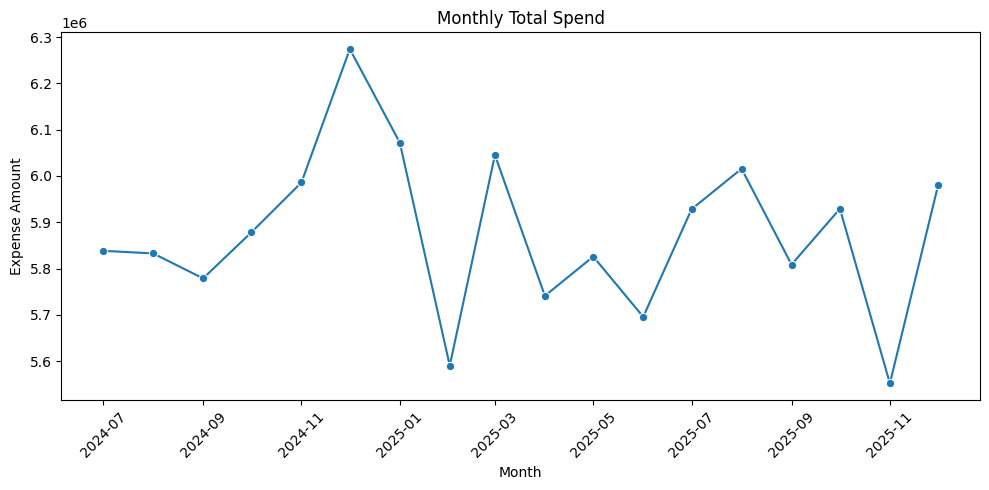

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Period to datetime for plotting
monthly_spend_plot = monthly_spend.copy()
monthly_spend_plot['year_month'] = monthly_spend_plot['year_month'].dt.to_timestamp()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_spend_plot, x='year_month', y='expense_approved_amount_rpt', marker='o')
plt.title('Monthly Total Spend')
plt.xlabel('Month')
plt.ylabel('Expense Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# Average Expense Amount - Overall
df["expense_approved_amount_rpt"].mean()

np.float64(1511.0364477142857)

In [6]:
df["expense_approved_amount_rpt"].describe()

count    70000.000000
mean      1511.036448
std        983.068731
min          7.780000
25%        707.002500
50%       1387.475000
75%       2182.720000
max       4497.550000
Name: expense_approved_amount_rpt, dtype: float64

In [7]:
dept_month_spend = (
    df.groupby(["transaction_year", "transaction_month", "department_name"])["expense_approved_amount_rpt"]
    .sum()
    .reset_index
)

dept_month_spend

<bound method Series.reset_index of transaction_year  transaction_month  department_name          
2024              August             Executive                    594070.31
                                     Finance                      585312.32
                                     Global Support & Services    599089.49
                                     IT & Security                542237.41
                                     Legal                        581267.57
                                                                    ...    
2025              September          Marketing                    560825.54
                                     People                       581146.21
                                     R&D                          594724.45
                                     WWFO                         498201.12
                                     Workplace                    571416.67
Name: expense_approved_amount_rpt, Length: 180, dtype: float64>

In [8]:
# Spend per Employee - Monthwise
emp_month_spend =(
    df.groupby(["transaction_year", "transaction_month", "employee_id"])["expense_approved_amount_rpt"]
    .sum()
    .reset_index()
)

emp_month_spend.head()

,transaction_year,transaction_month,employee_id,expense_approved_amount_rpt
0,2024,August,100279,859.86
1,2024,August,100335,2424.58
2,2024,August,101148,936.32
3,2024,August,101166,1232.28
4,2024,August,101243,631.07


In [9]:
# Policy & Risk Exploration

df["is_policy_risk"].value_counts()

is_policy_risk
False    35229
True     34771
Name: count, dtype: int64

In [10]:
policy_rate = df["is_policy_risk"].mean()*100
policy_rate

np.float64(49.67285714285714)

In [11]:
# Calculate policy risk rate

# Total unique transactions
total_transactions = df["report_id"].unique()

# Total risky transactions
risk_transactions = df[df["is_policy_risk"]==1]["report_id"].unique()

# Risk Rate
risk_rate = (len(risk_transactions) / len(total_transactions)) * 100

print(f"Policy Risk Rate: {risk_rate:.2f}%")

Policy Risk Rate: 49.67%


In [12]:
total_transactions = df["report_id"].nunique()
risk_transactions = df[df["is_policy_risk"]]["report_id"].nunique()
risk_rate = (risk_transactions / total_transactions) * 100
print(f"Policy Risk Rate: {risk_rate:.2f}%")

Policy Risk Rate: 49.67%


In [13]:
# Risk Rate by Department
risk_by_dept = (
    df.groupby("department_name")["is_policy_risk"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

risk_by_dept

department_name
Finance                      50.29
WWFO                         50.20
R&D                          49.92
Global Support & Services    49.72
Workplace                    49.70
IT & Security                49.64
Legal                        49.53
Executive                    49.46
Marketing                    49.44
People                       48.82
Name: is_policy_risk, dtype: float64

In [14]:
df["expense_approved_amount_rpt"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

count    70000.000000
mean      1511.036448
std        983.068731
min          7.780000
25%        707.002500
50%       1387.475000
75%       2182.720000
90%       2907.020000
95%       3342.032500
max       4497.550000
Name: expense_approved_amount_rpt, dtype: float64

In [15]:
(df["expense_approved_amount_rpt"] > 2200).mean() * 100

np.float64(24.545714285714286)

In [16]:
(df["expense_approved_amount_rpt"] > 3000).mean() * 100

np.float64(8.594285714285714)

In [17]:
df = pd.read_parquet("../data/feature/expense_features.parquet")

df[[
    "is_high_amount",
    "is_very_high_amount",
    "is_late_submission",
    "is_fx_impactful",
    "is_policy_risk"
]].mean() * 100

is_high_amount         24.545714
is_very_high_amount     8.594286
is_late_submission     13.114286
is_fx_impactful        17.472857
is_policy_risk         49.672857
dtype: float64

### Risk = Late Submission OR High Amount OR FX Impact

In [18]:
df.groupby("is_policy_risk")[
    ["is_high_amount",
     "is_very_high_amount",
     "is_late_submission",
     "is_fx_impactful"]
].mean()*100

,is_high_amount,is_very_high_amount,is_late_submission,is_fx_impactful
is_policy_risk,,,,
False,0.000000,0.000000,0.000000,0.000000
True,49.414742,17.301774,26.401311,35.175865


In [19]:
df.groupby("is_policy_risk")[[
    "is_high_amount",
    "is_late_submission",
    "is_fx_impactful"
]].mean()*100


,is_high_amount,is_late_submission,is_fx_impactful
is_policy_risk,,,
False,0.000000,0.000000,0.000000
True,49.414742,26.401311,35.175865


In [20]:
df["is_policy_risk"].sum()

np.int64(34771)

##### Policy risk = ANY financial OR operational OR compliance risk
##### That would combine:
##### is_high_amount
##### is_late_submission
##### is_fx_impactful

##### This creates one powerful executive metric:
##### Total Risky Expenses


In [24]:
# To understand overlap structure:
pd.crosstab(
    df["is_high_amount"],
    df["is_fx_impactful"]
)

is_fx_impactful,False,True
is_high_amount,,
False,40587,12231
True,17182,0


In [25]:
risk_monthly_sorted = (
    df.groupby(["transaction_year", "transaction_month"])["is_policy_risk"]
      .mean()
      .reset_index()
      .sort_values(["transaction_year", ("transaction_month")])
)

risk_monthly_sorted

,transaction_year,transaction_month,is_policy_risk
0,2024,August,0.479498
1,2024,December,0.512883
2,2024,July,0.484809
3,2024,November,0.502806
4,2024,October,0.487167
5,2024,September,0.497149
6,2025,April,0.480547
7,2025,August,0.496439
8,2025,December,0.495226
9,2025,February,0.506260


In [26]:
# Risk Expense - Monthwise
risk_month = (
    df[df["is_policy_risk"] == True]
    .groupby(["transaction_year", "transaction_month"])
    .size()
    .reset_index()
    .sort_values(["transaction_year", "transaction_month"])
)
risk_month

,transaction_year,transaction_month,0
0,2024,August,1871
1,2024,December,2090
2,2024,July,1883
3,2024,November,1971
4,2024,October,1936
5,2024,September,1918
6,2025,April,1828
7,2025,August,1952
8,2025,December,1971
9,2025,February,1860


In [27]:
df["year_month"] = pd.to_datetime(df["transaction_date"]).dt.to_period("M")
risk_month = (
    df[df["is_policy_risk"]]
    .groupby("year_month")
    .size()
    .reset_index(name="high_risk_count")
    .sort_values("year_month")
)

risk_month

,year_month,high_risk_count
0,2024-07,1883
1,2024-08,1871
2,2024-09,1918
3,2024-10,1936
4,2024-11,1971
5,2024-12,2090
6,2025-01,2011
7,2025-02,1860
8,2025-03,2012
9,2025-04,1828


In [28]:
high_amount_monthly = (
    df.groupby(["transaction_year", "transaction_month"])["is_high_amount"]
      .mean()
      .reset_index()
)

high_amount_monthly

,transaction_year,transaction_month,is_high_amount
0,2024,August,0.236802
1,2024,December,0.252025
2,2024,July,0.232492
3,2024,November,0.255867
4,2024,October,0.235279
5,2024,September,0.248315
6,2025,April,0.239485
7,2025,August,0.255595
8,2025,December,0.245729
9,2025,February,0.247686


In [29]:
# FX Exploration
df["fx_variance"].describe()

count    70000.000000
mean         0.212231
std        476.390574
min      -1491.360000
25%       -234.072500
50%          0.000000
75%        237.770000
max       1497.820000
Name: fx_variance, dtype: float64

In [30]:
df["is_fx_impactful"].mean()*100

np.float64(17.472857142857144)

In [31]:
df["fx_variance_pct"].describe(percentiles=[0.25,0.5,0.75,0.9,0.95])

count    70000.000000
mean        -0.088282
std          0.338515
min         -0.999990
25%         -0.287227
50%          0.000000
75%          0.182231
90%          0.279624
95%          0.307238
max          0.333324
Name: fx_variance_pct, dtype: float64

In [32]:
(df["fx_variance_pct"].abs() > 0.38).mean() * 100

np.float64(20.23428571428571)

In [33]:
df["fx_variance_pct"].abs().quantile([0.75, 0.90, 0.95])

0.75    0.323401
0.90    0.637052
0.95    0.796971
Name: fx_variance_pct, dtype: float64

In [34]:
## FX Impact - Monthwise %
fx_monthly = (
    df.groupby(["transaction_year", "transaction_month"])["is_fx_impactful"]
        .mean()
        .reset_index ()
)
fx_monthly

,transaction_year,transaction_month,is_fx_impactful
0,2024,August,0.160943
1,2024,December,0.179877
2,2024,July,0.176365
3,2024,November,0.179082
4,2024,October,0.173629
5,2024,September,0.173924
6,2025,April,0.172187
7,2025,August,0.169125
8,2025,December,0.172613
9,2025,February,0.179913


In [35]:
fx_impact_rate = df["is_fx_impactful"].astype(int).mean()*100
print(f"FX Impact Rate: {fx_impact_rate:.2f}%")

FX Impact Rate: 17.47%


In [36]:
avg_fx_variance_pct = df["fx_variance_pct"].mean()
print(f"Average FX Variance %: {avg_fx_variance_pct: .2f}%")

Average FX Variance %: -0.09%


In [37]:
# FX Variance focused on FX impacted transactions
avg_fx_variance_pct = (
    df.loc[df["is_fx_impactful"] == 1, "fx_variance_pct"]
      .mean()
)

print(f"Average FX Variance % (Impacted Only): {avg_fx_variance_pct:.2f}%")

Average FX Variance % (Impacted Only): -0.69%


In [38]:
# Total FX Variance 
total_fx_variance = df["fx_variance"].sum()
print(f"Total FX Variance: {total_fx_variance:,.2f}")

Total FX Variance: 14,856.14


In [39]:
fx_by_dept = (
    df.groupby("department_name")["is_fx_impactful"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

fx_by_dept

department_name
Legal                        17.92
Executive                    17.89
WWFO                         17.74
Finance                      17.64
IT & Security                17.62
Marketing                    17.43
Global Support & Services    17.39
R&D                          17.26
People                       17.03
Workplace                    16.85
Name: is_fx_impactful, dtype: float64

In [40]:
df["submission_delay_days"].describe()

count    70000.000000
mean         6.998043
std          4.300583
min          0.000000
25%          3.000000
50%          7.000000
75%         11.000000
max         14.000000
Name: submission_delay_days, dtype: float64

In [271]:
df["submission_delay_days"].quantile(0.90)

np.float64(13.0)

In [272]:
(df["submission_delay_days"] > 12).mean() * 100

np.float64(13.114285714285714)

In [41]:
late_monthly = (
    df.groupby(["transaction_year", "transaction_month"])["is_late_submission"]
        .mean()
        .reset_index()
)
late_monthly

,transaction_year,transaction_month,is_late_submission
0,2024,August,0.136084
1,2024,December,0.136933
2,2024,July,0.131050
3,2024,November,0.123214
4,2024,October,0.128586
5,2024,September,0.128823
6,2025,April,0.123028
7,2025,August,0.123856
8,2025,December,0.125377
9,2025,February,0.134731


In [42]:
# Employee Behavior Exploration
top_spenders = (
    df.groupby("employee_id")["expense_approved_amount_rpt"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

top_spenders

employee_id
522563    9531.40
613796    8779.65
143347    8609.64
770598    8590.26
272243    8183.16
243463    8137.36
478368    7785.96
359862    7780.36
492261    7666.00
406931    7604.37
Name: expense_approved_amount_rpt, dtype: float64

In [43]:
# Inactive employee spend 

inactive_spend = (
    df.loc[df["active"] == "No", "expense_approved_amount_rpt"]
        .sum()
)

print(f"Inactive Employee Spend: {inactive_spend:,.2f}")

Inactive Employee Spend: 53,045,280.57


In [44]:
# Inactive employee spend % 

total_spend = df["expense_approved_amount_rpt"].sum()
inactive_spend_pct = (inactive_spend / total_spend) * 100

print(f"Inactive Spend %: {inactive_spend_pct:.2f}%")

Inactive Spend %: 50.15%


In [45]:
# Identify Repeat Transactions 

# Identify duplicates based on employee + vendor + amount
df["is_repeat"] = df.duplicated(
    subset=["employee_id", "vendor", "expense_approved_amount_rpt"],
    keep=False
).astype(int)

In [46]:
# Calculate Repeat Rate
repeat_rate = df["is_repeat"].mean() * 100
print(f"Repeat Expense Rate: {repeat_rate:.2f}%")

Repeat Expense Rate: 0.00%


In [47]:
# Count of Repeat Transactions
repeat_count = df["is_repeat"].sum()
print(f"Repeat Expense Count: {repeat_count}")

Repeat Expense Count: 0


In [48]:
# Time-Based Repeat - Advanced
df = df.sort_values("transaction_date")

df["is_repeat"] = (
    df.groupby(["employee_id", "vendor", "expense_approved_amount_rpt"])
      .cumcount()
      .gt(0)
      .astype(int)
)

MoM Growth %=((Current Month Spend−Previous Month Spend)/Previous Month Spend)​×100

In [49]:
# Ensure date is proper
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

In [51]:
# Create Monthly Spend
monthly_spend = (
    df
    .assign(month=df["transaction_date"].dt.to_period("M"))
    .groupby("month")["expense_approved_amount_rpt"]
    .sum()
    .sort_index()
)
monthly_spend


month
2024-07    5838261.14
2024-08    5832637.94
2024-09    5778734.33
2024-10    5878429.19
2024-11    5985842.58
2024-12    6274117.80
2025-01    6071991.01
2025-02    5590212.23
2025-03    6045255.88
2025-04    5740939.91
2025-05    5825882.94
2025-06    5695635.69
2025-07    5928180.12
2025-08    6015570.29
2025-09    5808589.34
2025-10    5929061.94
2025-11    5551945.83
2025-12    5981263.18
Freq: M, Name: expense_approved_amount_rpt, dtype: float64

In [52]:
# Calculate MoM Growth % 
mom_growth = monthly_spend.pct_change() * 100
mom_growth = mom_growth.round(2)

mom_growth

month
2024-07     NaN
2024-08   -0.10
2024-09   -0.92
2024-10    1.73
2024-11    1.83
2024-12    4.82
2025-01   -3.22
2025-02   -7.93
2025-03    8.14
2025-04   -5.03
2025-05    1.48
2025-06   -2.24
2025-07    4.08
2025-08    1.47
2025-09   -3.44
2025-10    2.07
2025-11   -6.36
2025-12    7.73
Freq: M, Name: expense_approved_amount_rpt, dtype: float64

In [53]:
mom_df = pd.DataFrame({
    "monthly_spend": monthly_spend,
    "mom_growth_pct": monthly_spend.pct_change() * 100
})

mom_df = mom_df.round(2)

mom_df

,monthly_spend,mom_growth_pct
month,,
2024-07,5838261.14,NaN
2024-08,5832637.94,-0.10
2024-09,5778734.33,-0.92
2024-10,5878429.19,1.73
2024-11,5985842.58,1.83
2024-12,6274117.80,4.82
2025-01,6071991.01,-3.22
2025-02,5590212.23,-7.93
2025-03,6045255.88,8.14


#### | Positive Growth | Spending increasing | 
#### | Negative Growth | Spending decreasing | 
#### | High Volatility | Poor cost control | 

#### "is_outlier" Is Not Created Yet

In [54]:
# We will create this using IQR method.

# Calculate bounds
Q1 = df["expense_approved_amount_rpt"].quantile(0.25)
Q3 = df["expense_approved_amount_rpt"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [55]:
# Create Outlier Flag

df["is_outlier"] = (
    (df["expense_approved_amount_rpt"] < lower_bound) |
    (df["expense_approved_amount_rpt"] > upper_bound)
).astype(int)

In [56]:
# Count

outlier_count = df["is_outlier"].sum()
print(f"Outlier Expense Count: {outlier_count}")

Outlier Expense Count: 20


In [57]:
outlier_rate = df["is_outlier"].mean() * 100
print(f"Outlier Rate: {outlier_rate:.2f}%")

Outlier Rate: 0.03%


In [67]:
import pandas as pd

df_kpi = pd.read_parquet("../data/curated/expense_kpis.parquet")

df_kpi

,total_expense,total_transactions,avg_expense,policy_risk_rate
0,1.057726e+08,70000,1511.036448,0.496729


In [68]:
df_kpi = pd.read_parquet("../data/curated/kpi_category.parquet")

In [69]:
df_kpi

,category,expense_approved_amount_rpt
0,Ground Transport,16899384.55
1,Airfare,13922257.82
2,Other,9557857.69
3,Training,9375239.74
4,Meal,8389341.66
5,Hotel,8309627.05
6,HR,7566033.58
7,Financial Charges,5007129.77
8,Utilities,4843103.12
9,Entertainment,4780088.47


In [73]:
df_kpi = pd.read_parquet("../data/curated/kpi_travel_customer_matrix.parquet")
df_kpi

,is_travel,is_customer_facing,expense_approved_amount_rpt
0,False,False,55415986.29
1,False,True,0.00
2,True,False,39110137.87
3,True,True,11246427.18


In [74]:
df_features = pd.read_parquet("../data/feature/expense_features.parquet")

df_features.groupby(["is_travel", "is_customer_facing"]).size()

is_travel  is_customer_facing
False      False                 36735
True       False                 25889
           True                   7376
dtype: int64

In [64]:
df_kpi = pd.read_parquet("../data/curated/kpi_travel_split.parquet")
df_kpi

,is_travel,expense_approved_amount_rpt
0,False,55415986.29
1,True,50356565.05


In [4]:
df_kpi = pd.read_parquet("../data/curated/kpi_monthly_trend.parquet")
df_kpi

,year_month,expense_approved_amount_rpt
0,2024-07,5838261.14
1,2024-08,5832637.94
2,2024-09,5778734.33
3,2024-10,5878429.19
4,2024-11,5985842.58
5,2024-12,6274117.80
6,2025-01,6071991.01
7,2025-02,5590212.23
8,2025-03,6045255.88
9,2025-04,5740939.91


In [77]:
df_kpi = pd.read_parquet("../data/curated/kpi_approval_by_department.parquet")
df_kpi

,department_name,end_to_end_approval_days
0,Workplace,7.045815
1,People,7.040388
2,Legal,7.027535
3,Marketing,7.020893
4,Executive,7.017477
5,Finance,7.013069
6,R&D,6.994196
7,IT & Security,6.991763
8,Global Support & Services,6.986018
9,WWFO,6.930950


In [78]:
df_kpi = pd.read_parquet("../data/curated/kpi_approval_stage.parquet")
df_kpi

,submission_to_manager_avg,manager_to_accounting_avg
0,4.002229,3.004686


In [ ]:
df_kpi = pd.read_parquet("../data/curated/kpi_expense_per_active_employee.parquet")
df_kpi

,expense_per_active_employee
0,3098.018609


In [82]:
df_kpi = pd.read_parquet("../data/curated/kpi_fx_impact_pct.parquet")
df_kpi

,fx_impactful_pct
0,17.472857


In [83]:
df_kpi = pd.read_parquet("../data/curated/kpi_fx_summary.parquet")
df_kpi

,is_fx_impactful,expense_approved_amount_rpt
0,False,94650732.30
1,True,11121819.04


In [84]:
df_kpi = pd.read_parquet("../data/curated/kpi_high_risk_pct.parquet")
df_kpi

,high_risk_expense_pct
0,63.121253


In [86]:
df_kpi = pd.read_parquet("../data/curated/kpi_internal_overhead_ratio.parquet")
df_kpi

,internal_overhead_ratio
0,89.367348


In [ ]:
print(df[[
    "is_high_amount",
    "is_very_high_amount",
    "is_late_submission",
    "is_fx_impactful",
    "is_policy_risk"
]].mean())

is_high_amount         0.245457
is_very_high_amount    0.085943
is_late_submission     0.131143
is_fx_impactful        0.174729
is_policy_risk         0.496729
dtype: float64


In [88]:
print("Total rows:", len(df))
print("Risky rows:", df["is_policy_risk"].sum())
print("Risky %:", df["is_policy_risk"].mean() * 100)

total_spend = df["expense_approved_amount_rpt"].sum()
risky_spend = df[df["is_policy_risk"] == 1]["expense_approved_amount_rpt"].sum()

print("Risky spend %:", (risky_spend / total_spend) * 100)

Total rows: 70000
Risky rows: 34771
Risky %: 49.67285714285714
Risky spend %: 63.12125332534312


In [2]:
import pandas as pd

df = pd.read_parquet("../data/curated/kpi_department_spend.parquet")
print(df.columns)
print(df.head())

Index(['department_name', 'expense_approved_amount_rpt'], dtype='object')
  department_name  expense_approved_amount_rpt
0       Workplace                  10986795.42
1             R&D                  10758858.78
2            WWFO                  10607282.96
3       Executive                  10590685.65
4          People                  10581358.35


In [2]:
import pandas as pd
df = pd.read_parquet("../data/curated/kpi_mom_growth.parquet")
print(df.columns)
print(df.tail())

Index(['transaction_year', 'transaction_month', 'expense_approved_amount_rpt',
       'mom_growth_pct'],
      dtype='object')
    transaction_year transaction_month  expense_approved_amount_rpt  \
13              2025             March                   6045255.88   
14              2025               May                   5825882.94   
15              2025          November                   5551945.83   
16              2025           October                   5929061.94   
17              2025         September                   5808589.34   

    mom_growth_pct  
13        6.138388  
14       -3.628845  
15       -4.702070  
16        6.792503  
17       -2.031900  


In [8]:
df_kpi= pd.read_parquet("../data/curated/kpi_customer_split.parquet")
df_kpi

,is_customer_facing,expense_approved_amount_rpt
0,False,94526124.16
1,True,11246427.18


In [9]:
df_kpi= pd.read_parquet("../data/curated/kpi_country_spend.parquet")
df_kpi

,country,expense_approved_amount_rpt,total_transactions,spend_pct
0,Germany,10934180.73,7136,0.103374
1,Canada,10666372.89,6978,0.100843
2,United Kingdom,10636594.80,7045,0.100561
3,Singapore,10577895.39,7064,0.100006
4,Australia,10559111.87,7014,0.099828
5,France,10526882.24,6970,0.099524
6,Brazil,10506576.74,6968,0.099332
7,India,10488903.55,6986,0.099165
8,United States,10480033.95,6935,0.099081
9,Japan,10395999.18,6904,0.098286


In [10]:
df_kpi= pd.read_parquet("../data/curated/kpi_job_family_spend.parquet")
df_kpi

,job_family,expense_approved_amount_rpt,total_transactions,spend_pct
0,Software Engineering,52918678.62,34980,0.500306
1,Solutions Engineering,19477247.88,12938,0.184143
2,Strategic Account Management,13917609.18,9246,0.131581
3,Executive Assistant,10590685.65,7038,0.100127
4,Field Sales,8868330.01,5798,0.083843
